In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
  torch.cuda.manual_seed(30) # Ensure the smae parameters, make the results reproducable
  torch.cuda.manual_seed_all(30)
  device = torch.device("cuda")
else:
  torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [2]:
import os
from torchvision import datasets, transforms

data_path = os.getcwd()
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=True, transform=transforms.ToTensor())

100%|██████████| 170M/170M [03:05<00:00, 919kB/s]


In [3]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
torch.manual_seed(30) # Ensure the smae parameters, make the results reproducable

imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim=3)

train_mean = imgs.view(3, -1).mean(dim=1)

train_std =imgs.view(3, -1).std(dim=1)

cifar10_transforms = transforms.Compose([transforms.ToTensor(),transforms.Normalize(train_mean, train_std)])

cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform=cifar10_transforms)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False, transform=cifar10_transforms)

label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

In [7]:
import torch.nn.functional as F

class NetRes(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(16, 16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 4 * 4, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        identity = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + identity, 2)
        out = out.view(out.size(0), -1)

        out = torch.relu(self.fc1(out))
        out = self.fc2(out)

        return out

In [12]:
def training_loop(model, optimizer, train_loader, epoch):
    loss_fn = nn.CrossEntropyLoss()
    Loss = []

    for epoch in range(epoch):
        model.train()
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs, labels= imgs.to(device), labels.to(device)
            predictions = model(imgs)
            loss = loss_fn(predictions, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        avg_loss = loss_train / len(train_loader)
        Loss.append(avg_loss)
        if (epoch+1) % 10 == 0:
            print(f"Epoch: {epoch+1}, Loss: {avg_loss}")
    return Loss

def validate(model, val_loader):
    correct = 0
    total = 0

    model.eval()

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels= imgs.to(device), labels.to(device)
            predictions = model(imgs)
            _, predicted = torch.max(predictions.data, dim=1)
            total += labels.size(0)
            correct += int((predicted == labels).sum())

    accuracy = correct / total
    print(f"Validation Accuracy: {accuracy:.4f}")
    print(f"Validation Accuracy: {accuracy * 100:.2f}%")

    return accuracy

In [13]:
Learning_rate = 0.01
Epoch = 100
model = NetRes().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=Learning_rate)
loss = training_loop(model, optimizer, train_loader, Epoch)
accuracy = validate(model, val_loader)

Epoch: 10, Loss: 0.33148302185307643
Epoch: 20, Loss: 0.2899383637745669
Epoch: 30, Loss: 0.25588700165794154
Epoch: 40, Loss: 0.22907324543424473
Epoch: 50, Loss: 0.2007589404275463
Epoch: 60, Loss: 0.1799443994358087
Epoch: 70, Loss: 0.1582586373066067
Epoch: 80, Loss: 0.13415503399861847
Epoch: 90, Loss: 0.11455593663890651
Epoch: 100, Loss: 0.0942999799231625
Validation Accuracy: 0.8660
Validation Accuracy: 86.60%


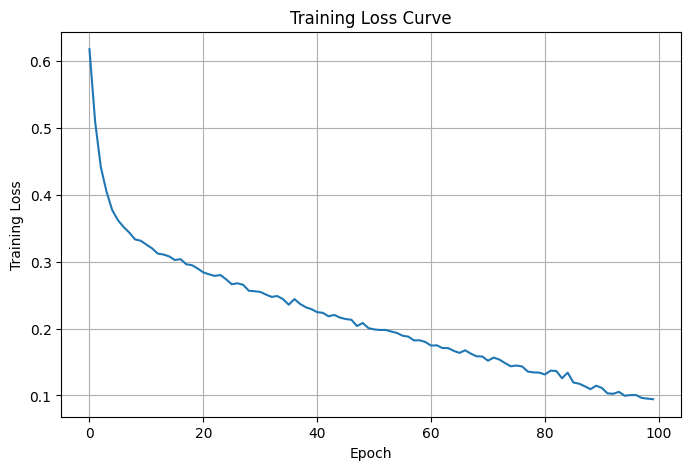

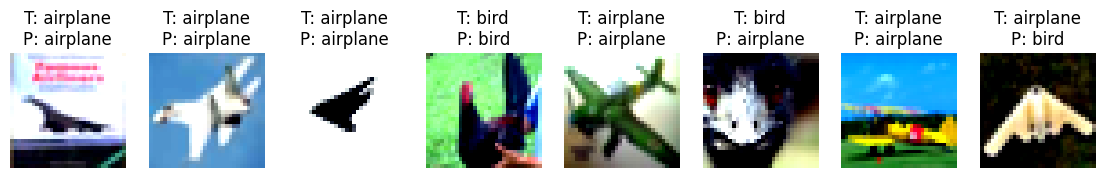

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(loss)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()



import matplotlib.pyplot as plt

class_names = ["airplane", "bird"]

def show_predictions(model, val_loader, num_images=8):
    model.eval()

    imgs, labels = next(iter(val_loader))
    imgs, labels = imgs.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(imgs)
        _, predicted = torch.max(outputs, dim=1)

    imgs = imgs.cpu()
    labels = labels.cpu()
    predicted = predicted.cpu()

    plt.figure(figsize=(14, 4))

    for i in range(num_images):
        img = imgs[i]

        # unnormalize
        img = img / 2 + 0.5

        # CHW -> HWC
        img = img.permute(1, 2, 0)

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.axis("off")

        true_name = class_names[labels[i]]
        pred_name = class_names[predicted[i]]

        plt.title(f"T: {true_name}\nP: {pred_name}")

    plt.show()

show_predictions(model, val_loader, num_images=8)